In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('bhp.csv')

In [18]:
df.price_per_sqft.describe()

,price_per_sqft
count,1.320000e+04
mean,7.920337e+03
std,1.067272e+05
min,2.670000e+02
25%,4.267000e+03
50%,5.438000e+03
75%,7.317000e+03
max,1.200000e+07


<Axes: xlabel='price_per_sqft', ylabel='Count'>

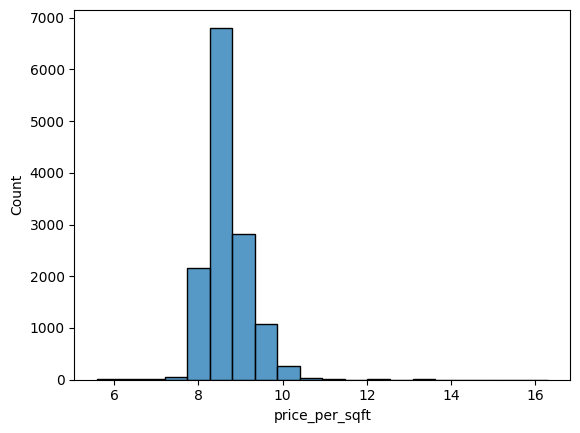

In [33]:
plt.plot(figsize = (10,6))
sns.histplot(np.log1p(df['price_per_sqft']), bins = 20)

In [34]:
max_threshold = df['price_per_sqft'].quantile(0.999)
min_threshold = df['price_per_sqft'].quantile(0.001)
print(max_threshold)
print(min_threshold)

50959.36200000098
1366.184


In [35]:
df2 = df[(df['price_per_sqft'] < max_threshold) & (df['price_per_sqft'] > min_threshold)]

In [38]:
df.shape[0] - df2.shape[0]

28

##4 Standard Deviation

In [43]:
upper_limit = df2['price_per_sqft'].mean() + 4 * df2['price_per_sqft'].std()
lower_limit = df2['price_per_sqft'].mean() - 4 * df2['price_per_sqft'].std()
df3 = df2[(df2['price_per_sqft'] < upper_limit) & (df2['price_per_sqft'] > lower_limit)]

In [44]:
df2.shape[0]-df3.shape[0]

125

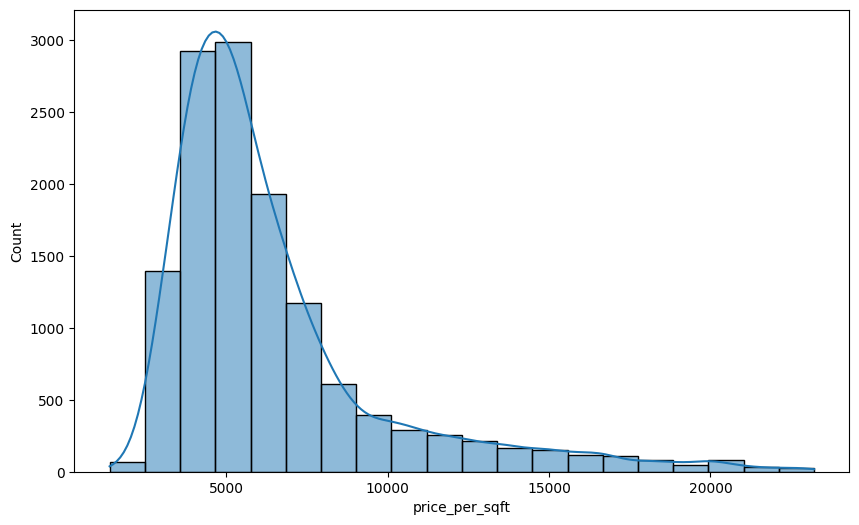

In [45]:
plt.figure(figsize = (10,6))
sns.histplot(df3['price_per_sqft'], kde = True, bins = 20)
plt.show()

## Z score

In [50]:
df2["zscore"] = ( df2.price_per_sqft - df2.price_per_sqft.mean() ) / df2.price_per_sqft.std()
df4 = df2[(df2["zscore"] < 4) & (df2["zscore"] > -4)]

<ipython-input-50-9e4ebcd8c417>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["zscore"] = ( df2.price_per_sqft - df2.price_per_sqft.mean() ) / df2.price_per_sqft.std()


In [51]:
df2.shape[0] - df4.shape[0]

125